# P3 — Exploratory Data Analysis
## P7 Operations — Branch-Month Order Counts

**Name:** Lawrence M. Lagdamen  
**Course:** BDAT05 — Fundamentals of Predictive Analytics  
**Term:** Term 1, AY 2026–2027  
**Track:** P7 · Operations

This notebook interrogates the validated P2 branch-month order count slice for predictive signal. The analysis examines the distribution of monthly orders, repeating patterns over time, unusual branch-months, predictor leakage, and the baseline a future model must beat.

## Reload the P2 Slice

I will reload the final P2 branch-month dataset from Google Drive and confirm that its structure and row count match the validated P2 output before starting the exploratory analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

P2_FILE = "/content/drive/MyDrive/p7_branch_month_order_counts.csv"

p3 = pd.read_csv(P2_FILE)

print("Shape:", p3.shape)
print("\nData types:")
print(p3.dtypes)

print("\nMissing values:")
print(p3.isna().sum())

display(p3.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (108, 3)

Data types:
BranchID      object
YearMonth     object
OrderCount     int64
dtype: object

Missing values:
BranchID      0
YearMonth     0
OrderCount    0
dtype: int64


,BranchID,YearMonth,OrderCount
0,B01,2025-01,131
1,B01,2025-02,128
2,B01,2025-03,139
3,B01,2025-04,138
4,B01,2025-05,132


### Reading the Output

The P2 slice reloaded successfully with 108 rows and 3 columns, matching the final P2 output. There are no missing values, so the dataset is ready for P3 exploratory analysis.

## Univariate Check — Is the Average Honest?

I will examine the distribution of `OrderCount` using summary statistics, skewness, and a histogram. The goal is to check whether the mean fairly represents a typical branch-month or whether the distribution is pulled by unusually high or low order counts.

count    108.000000
mean      97.722222
std       31.796324
min       34.000000
25%       79.750000
50%       94.500000
75%      119.500000
max      182.000000
Name: OrderCount, dtype: float64

Mean: 97.72222222222223
Median: 94.5
Skewness: 0.10404711594704825


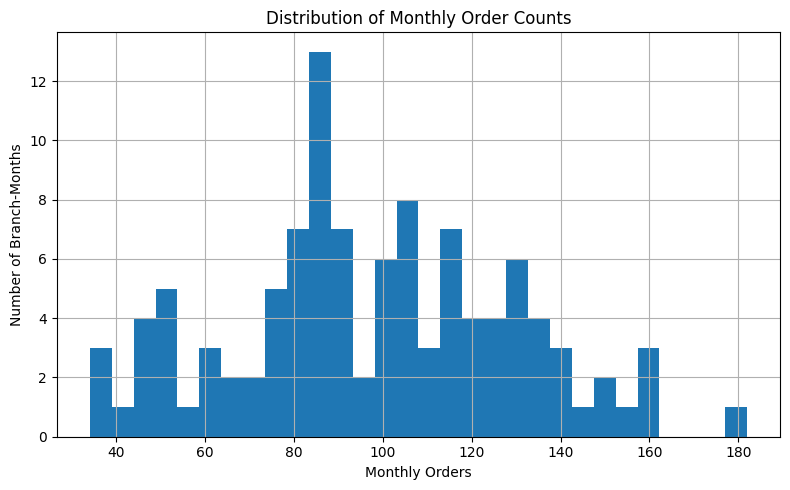

In [2]:
import matplotlib.pyplot as plt

print(p3["OrderCount"].describe())

mean_orders = p3["OrderCount"].mean()
median_orders = p3["OrderCount"].median()
skew_orders = p3["OrderCount"].skew()

print("\nMean:", mean_orders)
print("Median:", median_orders)
print("Skewness:", skew_orders)

plt.figure(figsize=(8, 5))

p3["OrderCount"].hist(bins=30)

plt.title("Distribution of Monthly Order Counts")
plt.xlabel("Monthly Orders")
plt.ylabel("Number of Branch-Months")

plt.tight_layout()
plt.show()

### Reading the Output

The mean OrderCount is 97.72 and the median is 94.50, while skewness is only 0.10. This indicates that the distribution is close to symmetric, so the mean is a reasonable summary of a typical branch-month. Predicting only the average would still miss the wide variation in monthly orders, which range from 34 to 182.

## The Rhythm — What Repeats?

### Discussion

I will plot monthly `OrderCount` for each branch to check whether demand follows a repeating pattern over time. I will also compare average orders by calendar month so any seasonal pattern can be described with an actual number.

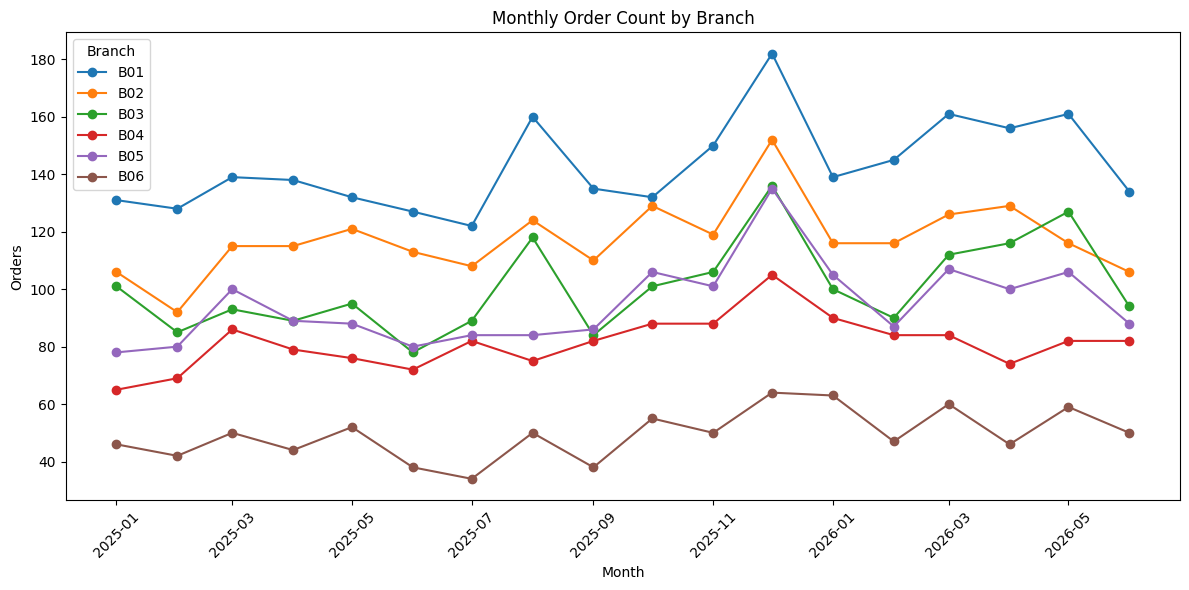

Average OrderCount by calendar month:
MonthNo
1      95.00
2      88.75
3     102.75
4      97.92
5     101.25
6      88.50
7      86.50
8     101.83
9      89.17
10    101.83
11    102.33
12    129.00
Name: OrderCount, dtype: float64

Overall monthly average: 97.72
Highest calendar-month average: 12
Average orders in that month: 129.0
Percent above overall average: 32.0 %


In [3]:
import matplotlib.pyplot as plt

rhythm = p3.copy()
rhythm["Date"] = pd.to_datetime(rhythm["YearMonth"] + "-01")
rhythm["MonthNo"] = rhythm["Date"].dt.month

plt.figure(figsize=(12, 6))

for branch, group in rhythm.groupby("BranchID"):
    plt.plot(
        group["Date"],
        group["OrderCount"],
        marker="o",
        label=branch
    )

plt.title("Monthly Order Count by Branch")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend(title="Branch")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_pattern = (
    rhythm.groupby("MonthNo")["OrderCount"]
    .mean()
    .round(2)
)

overall_mean = rhythm["OrderCount"].mean()

print("Average OrderCount by calendar month:")
print(monthly_pattern)

strongest_month = monthly_pattern.idxmax()
strongest_average = monthly_pattern.max()
strongest_pct = ((strongest_average / overall_mean) - 1) * 100

print("\nOverall monthly average:", round(overall_mean, 2))
print("Highest calendar-month average:", strongest_month)
print("Average orders in that month:", strongest_average)
print("Percent above overall average:", round(strongest_pct, 1), "%")

### Reading the Output

The strongest repeating pattern is the December increase in orders. December averages 129 orders per branch, which is about 32.0% above the overall monthly average of 97.72. The chart also shows persistent differences between branches, with B01 generally recording the highest order counts and B06 the lowest, suggesting that both seasonality and branch identity may be useful predictors.

## Extremes — Real Signal or Bad Data?

### Discussion

I will use the IQR rule to identify branch-month order counts that fall beyond the expected range. Any extreme row will be reviewed before deciding whether it should be kept, flagged, or dropped.

In [4]:
q1 = p3["OrderCount"].quantile(0.25)
q3 = p3["OrderCount"].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = p3[
    (p3["OrderCount"] < lower_fence) |
    (p3["OrderCount"] > upper_fence)
].copy()

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)
print("Rows beyond the fences:", len(outliers))

display(outliers)

if len(outliers) > 0:
    outliers["DistanceBeyondFence"] = outliers.apply(
        lambda row:
        lower_fence - row["OrderCount"]
        if row["OrderCount"] < lower_fence
        else row["OrderCount"] - upper_fence,
        axis=1
    )

    extreme_row = outliers.sort_values(
        "DistanceBeyondFence",
        ascending=False
    ).iloc[0]

    print("\nMost extreme row:")
    print(extreme_row[["BranchID", "YearMonth", "OrderCount"]])

Q1: 79.75
Q3: 119.5
IQR: 39.75
Lower fence: 20.125
Upper fence: 179.125
Rows beyond the fences: 1


,BranchID,YearMonth,OrderCount
11,B01,2025-12,182



Most extreme row:
BranchID          B01
YearMonth     2025-12
OrderCount        182
Name: 11, dtype: object


### Reading the Output

The IQR check identifies only one extreme row: B01 in December 2025 with 182 orders, slightly above the upper fence of 179.13. I would **KEEP** this row because December already showed the strongest seasonal increase in the previous analysis, so the value is consistent with a real demand pattern rather than an obvious data error.

## Hunt the Leak

### Discussion

The prediction is made on the first morning of the month, so a predictor is only valid if Kape Tayo could already know it at that time. I will inspect the supplied leak dataset and apply the day-1 calendar test to each candidate predictor.

In [5]:
LEAK_FILE = "/content/drive/MyDrive/hunt_the_leak.csv"

leak = pd.read_csv(LEAK_FILE)

print("Shape:", leak.shape)

print("\nColumns:")
print(leak.columns.tolist())

display(leak.head())

leakage_audit = pd.DataFrame({
    "Column": [
        "MonthNo",
        "PromoDaysPlanned",
        "StaffHoursScheduled",
        "PrevMonthOrders",
        "PrevMonthRevenue",
        "OrderCount",
        "AvgTicket",
        "MonthSalesTotal",
        "RefundsProcessed",
        "QuarterRevenueTotal"
    ],
    "Knowable day 1?": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],
    "Verdict": [
        "KEEP",
        "KEEP",
        "KEEP",
        "KEEP",
        "KEEP",
        "LEAK",
        "LEAK",
        "LEAK",
        "LEAK",
        "LEAK"
    ],
    "Why": [
        "The calendar month is known before the month begins.",
        "Planned promotion days are scheduled in advance.",
        "Scheduled staff hours are set before the month begins.",
        "The previous month's order count already exists by day 1.",
        "The previous month's revenue already exists by day 1.",
        "This month's total orders are only known as the month happens.",
        "This month's average ticket requires this month's transactions.",
        "This month's sales total is only known during or after the month.",
        "Refunds processed during the month are not known on day 1.",
        "Quarter revenue includes revenue from the current or future months of the quarter."
    ]
})

display(leakage_audit)

Shape: (102, 13)

Columns:
['BranchID', 'YearMonth', 'MonthNo', 'PromoDaysPlanned', 'StaffHoursScheduled', 'PrevMonthOrders', 'PrevMonthRevenue', 'OrderCount', 'AvgTicket', 'MonthSalesTotal', 'RefundsProcessed', 'QuarterRevenueTotal', 'MonthRevenue_TARGET']


,BranchID,YearMonth,MonthNo,PromoDaysPlanned,StaffHoursScheduled,PrevMonthOrders,PrevMonthRevenue,OrderCount,AvgTicket,MonthSalesTotal,RefundsProcessed,QuarterRevenueTotal,MonthRevenue_TARGET
0,B01,2025-02,2,4,271.0,131.0,32340.0,128,211.64,27090.0,3.0,91910.0,27090.0
1,B01,2025-03,3,4,282.0,128.0,27090.0,139,233.67,32480.0,3.0,91910.0,32480.0
2,B01,2025-04,4,6,291.0,139.0,32480.0,138,226.20,31215.0,3.0,94705.0,31215.0
3,B01,2025-05,5,4,303.0,138.0,31215.0,132,251.25,33165.0,3.0,94705.0,33165.0
4,B01,2025-06,6,5,306.0,132.0,33165.0,127,238.78,30325.0,2.0,94705.0,30325.0


,Column,Knowable day 1?,Verdict,Why
0,MonthNo,Yes,KEEP,The calendar month is known before the month b...
1,PromoDaysPlanned,Yes,KEEP,Planned promotion days are scheduled in advance.
2,StaffHoursScheduled,Yes,KEEP,Scheduled staff hours are set before the month...
3,PrevMonthOrders,Yes,KEEP,The previous month's order count already exist...
4,PrevMonthRevenue,Yes,KEEP,The previous month's revenue already exists by...
5,OrderCount,No,LEAK,This month's total orders are only known as th...
6,AvgTicket,No,LEAK,This month's average ticket requires this mont...
7,MonthSalesTotal,No,LEAK,This month's sales total is only known during ...
8,RefundsProcessed,No,LEAK,Refunds processed during the month are not kno...
9,QuarterRevenueTotal,No,LEAK,Quarter revenue includes revenue from the curr...


### Reading the Output

Five predictors pass the day-1 calendar test: `MonthNo`, `PromoDaysPlanned`, `StaffHoursScheduled`, `PrevMonthOrders`, and `PrevMonthRevenue`. The other five are leakage because their values depend on information from the month being predicted.

The sneakiest leak is `QuarterRevenueTotal` because it looks like a normal summary variable, but it can already contain revenue from the target month. A beginner could easily keep it without noticing that it gives the model information that would not yet exist on day 1.

## Branch Comparison — Does Location Matter?

### Discussion

The time-series chart suggests that branches operate at different demand levels. I will compare the average monthly `OrderCount` across branches to see whether branch identity may provide useful predictive signal.

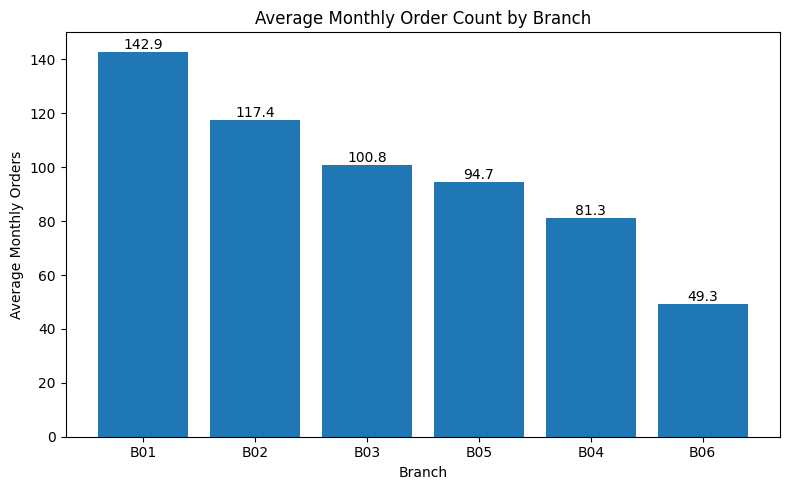

Average monthly orders by branch:
BranchID
B01    142.89
B02    117.39
B03    100.78
B05     94.67
B04     81.28
B06     49.33
Name: OrderCount, dtype: float64

Highest-average branch: B01 142.89
Lowest-average branch: B06 49.33
Difference: 93.56 orders


In [6]:
branch_avg = (
    p3.groupby("BranchID")["OrderCount"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(branch_avg.index, branch_avg.values)

ax.bar_label(bars, fmt="%.1f")

ax.set_title("Average Monthly Order Count by Branch")
ax.set_xlabel("Branch")
ax.set_ylabel("Average Monthly Orders")

plt.tight_layout()
plt.show()

print("Average monthly orders by branch:")
print(branch_avg.round(2))

highest_branch = branch_avg.idxmax()
lowest_branch = branch_avg.idxmin()

print("\nHighest-average branch:", highest_branch, round(branch_avg.max(), 2))
print("Lowest-average branch:", lowest_branch, round(branch_avg.min(), 2))
print(
    "Difference:",
    round(branch_avg.max() - branch_avg.min(), 2),
    "orders"
)

### Reading the Output

Branch identity shows a strong difference in monthly demand. B01 has the highest average at 142.89 orders per month, while B06 has the lowest at 49.33, a gap of 93.56 orders. This suggests that branch location is an important predictive signal because expected demand differs substantially across branches.

## Leakage Audit — My P7 Predictors

### Discussion

My P1 proposed historical inventory, staffing, and storage-condition data as candidate predictors. The P3 EDA also found strong differences by branch and a repeating monthly pattern, so I will add branch identity, calendar month, and previous-month orders as candidates. Each predictor must pass the same calendar test: could it be known before the month being predicted?

In [7]:
my_predictor_audit = pd.DataFrame({
    "My candidate predictor": [
        "Historical inventory level",
        "Historical staffing level",
        "Historical storage condition",
        "BranchID",
        "MonthNo",
        "PrevMonthOrders"
    ],
    "Knowable in advance?": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ],
    "Verdict": [
        "KEEP",
        "KEEP",
        "KEEP",
        "KEEP",
        "KEEP",
        "KEEP"
    ],
    "Why": [
        "Past inventory records already exist before the prediction month.",
        "Past staffing records already exist before the prediction month.",
        "Historical storage-condition records are available before the prediction month.",
        "The branch being forecast is known before the month starts.",
        "The calendar month is known in advance and may capture seasonality.",
        "The previous month's order count is already complete before the new month begins."
    ]
})

display(my_predictor_audit)

,My candidate predictor,Knowable in advance?,Verdict,Why
0,Historical inventory level,Yes,KEEP,Past inventory records already exist before th...
1,Historical staffing level,Yes,KEEP,Past staffing records already exist before the...
2,Historical storage condition,Yes,KEEP,Historical storage-condition records are avail...
3,BranchID,Yes,KEEP,The branch being forecast is known before the ...
4,MonthNo,Yes,KEEP,The calendar month is known in advance and may...
5,PrevMonthOrders,Yes,KEEP,The previous month's order count is already co...


### Reading the Output

All six candidate predictors pass the calendar test because they can be known before the target month begins. The EDA-supported predictors `BranchID` and `MonthNo` are especially useful because the earlier analysis showed clear differences between branches and a repeating December increase in orders. `PrevMonthOrders` may also help capture recent demand without using information from the month being predicted.

## Base Rate — How Wide Is the Demand Gap?

### Discussion

I will compare the quietest and busiest branch-months in the P2 slice. The ratio between them gives a simple baseline for how much demand can vary across branch-months before building a predictive model.

In [8]:
quietest = p3.loc[p3["OrderCount"].idxmin()]
busiest = p3.loc[p3["OrderCount"].idxmax()]

base_rate_ratio = quietest["OrderCount"] / busiest["OrderCount"]

print("Quietest branch-month:")
print(quietest)

print("\nBusiest branch-month:")
print(busiest)

print("\nQuietest ÷ busiest ratio:", round(base_rate_ratio, 3))
print("Percentage:", round(base_rate_ratio * 100, 1), "%")

Quietest branch-month:
BranchID          B06
YearMonth     2025-07
OrderCount         34
Name: 96, dtype: object

Busiest branch-month:
BranchID          B01
YearMonth     2025-12
OrderCount        182
Name: 11, dtype: object

Quietest ÷ busiest ratio: 0.187
Percentage: 18.7 %


### Reading the Output

The quietest branch-month is B06 in July 2025 with 34 orders, while the busiest is B01 in December 2025 with 182 orders. The quietest month is only 18.7% of the busiest, showing a very wide demand gap across branch-months. A useful model will need to explain this variation rather than predict nearly the same order level for every branch and month.

## Predictive-Signal Memo

**To: Operations Manager**

1. The clearest predictable pattern is branch-level demand, with B01 averaging 142.89 orders per month and B06 averaging 49.33, a difference of 93.56 orders.
2. There is also a seasonal December increase, with an average of 129 orders per branch, about 32.0% above the overall monthly average of 97.72.
3. I considered `QuarterRevenueTotal`, but it fails the calendar test because a 3-month quarter total can already include revenue from the month being predicted.
4. Any model must account for the 18.7% quietest-to-busiest branch-month base rate, which shows how much demand a single flat forecast would smear over.
5. In Week 6, I will first try predicting 1-month-ahead `OrderCount` using `BranchID`, `MonthNo`, and `PrevMonthOrders`.